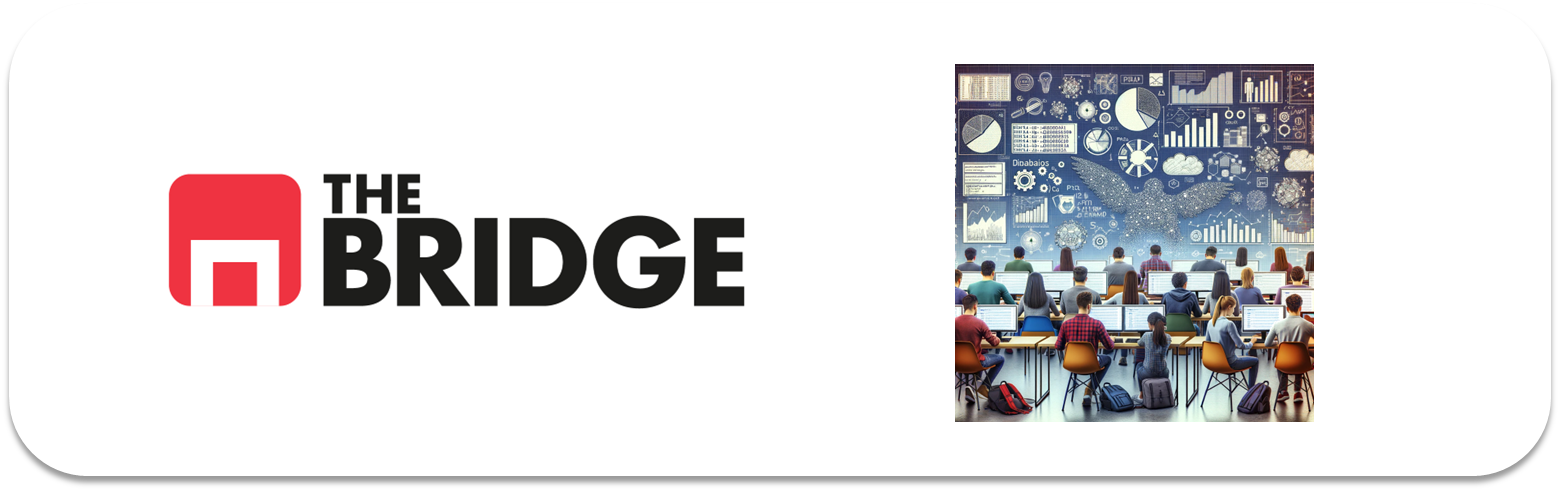

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

sns.set_style('whitegrid')

1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.

In [80]:
casas = pd.read_csv('data/hard_to_find/obligatoria_hard.csv',sep='|')
casas.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [81]:
casas.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [82]:
casas.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.

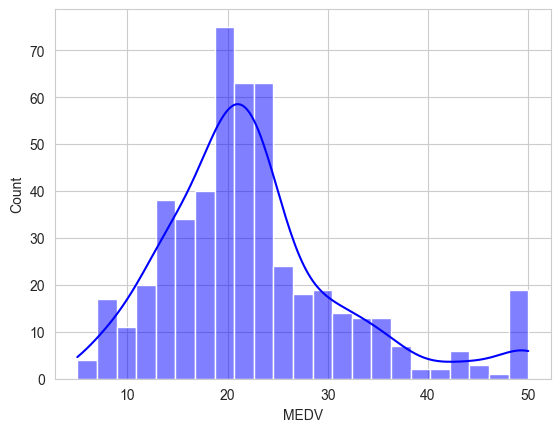

In [83]:
sns.histplot(casas['MEDV'], color='Blue', kde = True)
plt.show()

La distribución parece normal si no fuera por la cola en los valores alto, lo que indica que probablemente hay un agrupamiento de todos los valores que son mayores de 50 y equipararlo a 50. Seguiremos para adelante pero tendremos en cuenta que nos puede desvirtuar las predicciones, por lo que puede que tengamos que eliminar datos

3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test

In [84]:
features = casas.drop('MEDV', axis=1)
target = casas['MEDV']
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=42)

In [85]:
features_train.shape, features_test.shape, target_train.shape, target_test.shape

((379, 12), (127, 12), (379,), (127,))

5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.

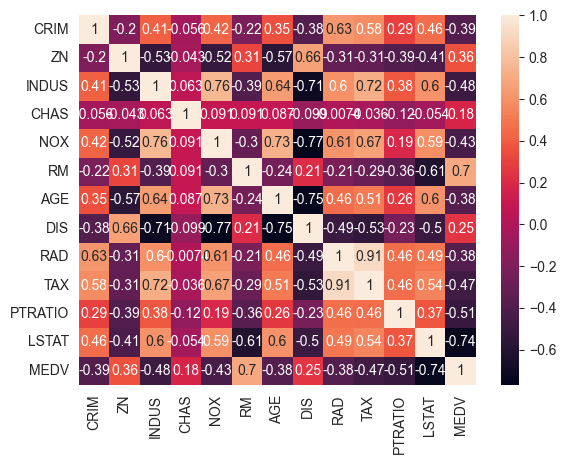

In [86]:
correlacion = casas.corr(numeric_only= True)
sns.heatmap(correlacion,annot=True);
plt.show();

6. Trata las variables para que funcionen lo mejor posible en el modelo.

Voy a filtrar todas las variables que tengan menos de 0.25 de correlación en valor absoluto

In [87]:
# Selecciono las variables cuya correlación absoluta con MEDV es >= 0.25
selected_features = correlacion['MEDV'][abs(correlacion['MEDV']) >= 0.25].index.tolist()
# Quito 'MEDV' porque es la variable objetivo, no una característica
selected_features.remove('MEDV')

# Filtro X_train y X_test para quedarme solo con las features seleccionadas
features_train = features_train[selected_features]
features_test = features_test[selected_features]

# Muestro las features seleccionadas y las dimensiones de los conjuntos resultantes
print("Selected features:", selected_features)
print("Features train shape:", features_train.shape)
print("Features test shape:", features_test.shape)

Selected features: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']
Features train shape: (379, 10)
Features test shape: (127, 10)


7. Construye un modelo de regresión lineal.

In [88]:
lm = LinearRegression()
lm.fit(features_train, target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


8. Analiza si lo crees conveniente los pesos y la importancia de las features.

In [89]:
lm.intercept_

np.float64(24.183924075156316)

In [90]:
lm.coef_

array([-0.11429229, -0.00904004,  0.12791476, -8.76271843,  4.57117003,
        0.02441324,  0.24709462, -0.01127396, -1.00759955, -0.57855492])

In [91]:
coef_df = pd.DataFrame(lm.coef_, features_train.columns, 
                      columns=['Coefficient'])
coef_df

,Coefficient
CRIM,-0.114292
ZN,-0.009040
INDUS,0.127915
NOX,-8.762718
RM,4.571170
AGE,0.024413
RAD,0.247095
TAX,-0.011274
PTRATIO,-1.007600
LSTAT,-0.578555


In [92]:
predictions = lm.predict(features_test)
predictions

array([27.54637529, 30.76277489, 14.4103924 , 24.86206221, 18.77204866,
       23.48634482, 18.1284182 , 12.71293832, 22.68625628, 19.20560627,
       21.85303228, 22.5293857 , -5.03002563, 22.5547903 , 20.14026811,
       25.46722313, 20.53377663,  3.82863221, 38.48508104, 17.44649585,
       25.40418001, 27.36142278, 12.08628638, 22.92151745, 18.17094144,
       15.17111878, 22.37223023, 19.45968693, 19.85876211, 18.04640195,
       20.52147785, 25.52521076, 24.48977591, 18.36349182, 16.35761835,
       20.05701847, 32.80999592, 20.97637197, 21.0429658 , 24.46527287,
       12.18034779, 29.37750436, 39.508091  , 18.19940277, 25.69458335,
       16.22196545, 14.50987281, 25.74793858, 19.80453269, 29.86133391,
       24.70087552, 34.43541977, 16.22190069, 24.85688893, 38.17350355,
       23.03810883, 18.70665469, 29.48610537, 24.94538555, 16.35522256,
       26.02891244, 31.5332413 , 29.79089573, 15.85726793, 25.93674008,
       13.83873746, 19.58587239, 25.22422415, 27.77056036, 16.25

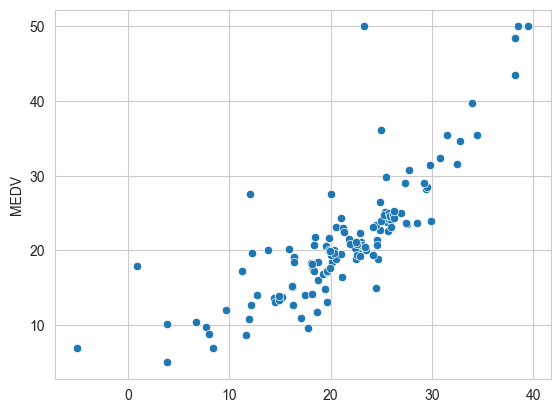

In [93]:
sns.scatterplot(x=predictions,y=target_test);
plt.show()

Se ve una cierta tendencia pero está estimando medidas por debajo de lo real en todos los casos

9. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.

In [94]:
pred_train = lm.predict(features_train)
print('MAE train', metrics.mean_absolute_error(target_train, pred_train))
print('MSE train', metrics.mean_squared_error(target_train, pred_train))
print('RMSE train', np.sqrt(metrics.mean_squared_error(target_train, pred_train)))
print('R2 train', lm.score(features_train, target_train))

MAE train 3.6478485398708203
MSE train 26.21582511258893
RMSE train 5.120139169259849
R2 train 0.7043830261585895


In [95]:
print('MAE test', metrics.mean_absolute_error(target_test, predictions))
print('MSE test', metrics.mean_squared_error(target_test, predictions))
print('RMSE test', np.sqrt(metrics.mean_squared_error(target_test, predictions)))
print('R2 test', lm.score(features_test, target_test))

MAE test 3.2309149768702277
MSE test 24.0094465952088
RMSE test 4.899943529797951
R2 test 0.6571408550698632


10. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.

### Ridge

In [ ]:
ridgeR = Ridge(alpha = 10) # alpha es lambda 
ridgeR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE:", round(metrics.mean_squared_error(target_train, ridgeR.predict(features_train)),2))
print("Test MSE:", round(metrics.mean_squared_error(target_test, ridgeR.predict(features_test)),2))
# print("Test RMSE:", np.sqrt(metrics.mean_squared_error(target_test, ridgeR.predict(features_test))))

Train MSE sin regularización: 26.22
Test MSE sin regularización: 24.01
Train MSE: 26.46
Test MSE: 24.18


In [ ]:
ridgeR = Ridge(alpha = 5) # alpha es lambda 
ridgeR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE:", round(metrics.mean_squared_error(target_train, ridgeR.predict(features_train)),2))
print("Test MSE:", round(metrics.mean_squared_error(target_test, ridgeR.predict(features_test)),2))
# print("Test RMSE:", np.sqrt(metrics.mean_squared_error(target_test, ridgeR.predict(features_test))))

Train MSE sin regularización: 26.22
Test MSE sin regularización: 24.01
Train MSE: 26.39
Test MSE: 24.25


In [112]:
ridgeR = Ridge(alpha = 15) # alpha es lambda 
ridgeR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE:", round(metrics.mean_squared_error(target_train, ridgeR.predict(features_train)),2))
print("Test MSE:", round(metrics.mean_squared_error(target_test, ridgeR.predict(features_test)),2))
# print("Test RMSE:", np.sqrt(metrics.mean_squared_error(target_test, ridgeR.predict(features_test))))

Train MSE sin regularización: 26.22
Test MSE sin regularización: 24.01
Train MSE: 26.53
Test MSE: 24.1


### LASSO

In [103]:
lassoR = Lasso(alpha=0.1)
lassoR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, lassoR.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, lassoR.predict(features_test)))

Train MSE sin regularización: 26.22
Test MSE sin regularización: 24.01
Train MSE: 26.5114
Test MSE: 24.3573


In [105]:
lassoR = Lasso(alpha=0.07)
lassoR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, lassoR.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, lassoR.predict(features_test)))

Train MSE sin regularización: 26.22
Test MSE sin regularización: 24.01
Train MSE: 26.4943
Test MSE: 24.4193


In [104]:
lassoR = Lasso(alpha=0.025)
lassoR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, lassoR.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, lassoR.predict(features_test)))

Train MSE sin regularización: 26.22
Test MSE sin regularización: 24.01
Train MSE: 26.4087
Test MSE: 24.4058


### Elastic Net

In [114]:
elastic_net = ElasticNet(alpha = 0.5, l1_ratio = 0.5)
elastic_net.fit(features_train, target_train)
print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, elastic_net.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, elastic_net.predict(features_test)))

Train MSE sin regularización: 26.22
Test MSE sin regularización: 24.01
Train MSE: 28.3569
Test MSE: 24.1788


In [115]:
elastic_net = ElasticNet(alpha = 0.05, l1_ratio = 0.5)
elastic_net.fit(features_train, target_train)
print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, elastic_net.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, elastic_net.predict(features_test)))

Train MSE sin regularización: 26.22
Test MSE sin regularización: 24.01
Train MSE: 26.5254
Test MSE: 24.2300


In [117]:
elastic_net = ElasticNet(alpha = 0.05, l1_ratio = 0.3)
elastic_net.fit(features_train, target_train)
print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, elastic_net.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, elastic_net.predict(features_test)))

Train MSE sin regularización: 26.22
Test MSE sin regularización: 24.01
Train MSE: 26.5407
Test MSE: 24.1411


11. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?